<a href="https://colab.research.google.com/github/annabanna19/bank-marketing-analysis/blob/main/Bank_Marketing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Marketing Campaign Analysis
Data: UCI Machine Learning Repository, Bank Marketing dataset (Moro, Cortez & Rita, 2014).

- Analysed 45,211 contacts from a bank's direct-marketing campaigns to identify what is associated with sign-up (11.7% overall).
- Customers who responded to a previous campaign signed up at 64.7%, and this remained the strongest predictor in a logit model (+43.8 percentage points).
- Over-65s and 18 to 25 year olds also converted well above average, an effect that persisted after controlling for occupation.
- Previous non-responders' apparent advantage over never-contacted customers was not significant once other factors were controlled for.
- **Recommendation:** prioritise previous responders and refine targeting by customer characteristics; investigate the 29% of contacts with no recorded channel (which converted at 4.1%) before relying on that data.
- **Methods:** Python (pandas) for cleaning and analysis, including treating coded missing values and excluding call duration (only known after the call); matplotlib for visualisation; logit with average marginal effects (statsmodels).

In [1]:
!wget -q "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip" -O uci.zip
!unzip -o -q uci.zip
!unzip -o -q bank.zip
!ls

bank-additional.zip  bank-full.csv   bank.zip	  uci.zip
bank.csv	     bank-names.txt  sample_data


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("bank-full.csv", sep=";")
print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
print((df == "unknown").sum())
print()
print(df["y"].value_counts(normalize=True))

age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


In [4]:
# Remove call duration: it's only known after the call, so it can't be used to decide who to call
df_clean = df.drop(columns=["duration"])

# 1 = subscribed, 0 = didn't
df_clean["subscribed"] = (df_clean["y"] == "yes").astype(int)

# Age bands for grouping customers
df_clean["age_band"] = pd.cut(df_clean["age"],
                              bins=[17, 25, 35, 45, 55, 65, 100],
                              labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"])

# Was the customer contacted in a previous campaign? (pdays = -1 means never)
df_clean["prev_contacted"] = (df_clean["pdays"] != -1).astype(int)

# Check: are the poutcome "unknowns" just customers never contacted before?
pd.crosstab(df_clean["poutcome"], df_clean["prev_contacted"])

prev_contacted,0,1
poutcome,,
failure,0,4901
other,0,1840
success,0,1511
unknown,36954,5


In [5]:
df_clean.loc[df_clean["prev_contacted"] == 0, "poutcome"] = "not contacted"
print(df_clean["poutcome"].value_counts())

poutcome
not contacted    36954
failure           4901
other             1840
success           1511
unknown              5
Name: count, dtype: int64


Data cleaning: 45,211 customers, 17 variables. Removed call duration because it's only known after a call, so it can't inform who to target. Missing values are coded as "unknown". 82% of previous-outcome values were "unknown", but nearly all (36,954 of 36,959) were customers never contacted before, so I relabelled them "not contacted" rather than deleting them. The overall sign-up rate is 11.7%.

In [6]:
age_rates = df_clean.groupby("age_band", observed=True)["subscribed"].agg(["mean", "count"])
age_rates["mean"] = (age_rates["mean"] * 100).round(1)
age_rates.columns = ["sign_up_rate_%", "customers"]
age_rates

,sign_up_rate_%,customers
age_band,,
18-25,24.0,1336
26-35,12.0,15571
36-45,9.4,13856
46-55,9.4,9548
56-65,14.1,4149
66+,42.6,751


Finding 1, age: Sign-up follows a U-shape. 18 to 25 year olds (24.0%) and over-65s (42.6%) convert far above the 11.7% average, while 36 to 55 year olds convert at 9.4%. Yet 26 to 55 year olds make up about 86% of contacts, so the campaign mostly targeted its lowest-converting groups. Caveat: the over-65 group is small (751), and age may reflect employment status, which I check next.

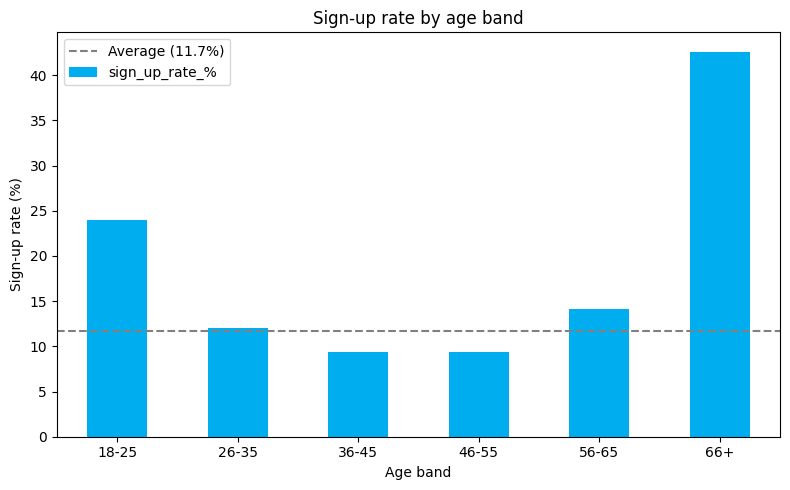

In [7]:
baseline = df_clean["subscribed"].mean() * 100

ax = age_rates["sign_up_rate_%"].plot(kind="bar", color="#00AEEF", figsize=(8, 5))
ax.axhline(baseline, color="grey", linestyle="--", label=f"Average ({baseline:.1f}%)")
ax.set_title("Sign-up rate by age band")
ax.set_xlabel("Age band")
ax.set_ylabel("Sign-up rate (%)")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Finding 2, job: Students (28.7%) and retirees (22.8%) convert most, which is consistent with the age pattern. Blue-collar workers are the largest group contacted (9,732) but convert least (7.3%). Retirees convert less than over-65s overall, suggesting age matters beyond employment status. I test this later with a logit model.

In [8]:
job_rates = df_clean.groupby("job")["subscribed"].agg(["mean", "count"])
job_rates["mean"] = (job_rates["mean"] * 100).round(1)
job_rates.columns = ["sign_up_rate_%", "customers"]
job_rates.sort_values("sign_up_rate_%", ascending=False)

,sign_up_rate_%,customers
job,,
student,28.7,938
retired,22.8,2264
unemployed,15.5,1303
management,13.8,9458
admin.,12.2,5171
unknown,11.8,288
self-employed,11.8,1579
technician,11.1,7597
services,8.9,4154


In [9]:
for col in ["poutcome", "contact"]:
    rates = df_clean.groupby(col)["subscribed"].agg(["mean", "count"])
    rates["mean"] = (rates["mean"] * 100).round(1)
    rates.columns = ["sign_up_rate_%", "customers"]
    print(rates.sort_values("sign_up_rate_%", ascending=False))
    print()

               sign_up_rate_%  customers
poutcome                                
success                  64.7       1511
unknown                  40.0          5
other                    16.7       1840
failure                  12.6       4901
not contacted             9.2      36954

           sign_up_rate_%  customers
contact                             
cellular             14.9      29285
telephone            13.4       2906
unknown               4.1      13020



Finding 3, previous engagement: Customers who responded positively to a previous campaign converted at 64.7%, about 5.5 times the average, and even previous non-responders (12.6%) outperformed never-contacted customers (9.2%). Yet 82% of calls went to never-contacted customers. Prioritising previous responders looks like the clearest targeting improvement.(Note: Finding 5 shows this gap is not significant once age, job and channel are controlled for.)

Finding 4, channel: Mobile (14.9%) and landline (13.4%) perform similarly, but customers with an unrecorded channel converted at only 4.1%. This suggests the missing values aren't random, which is a data-quality issue to investigate before drawing conclusions.

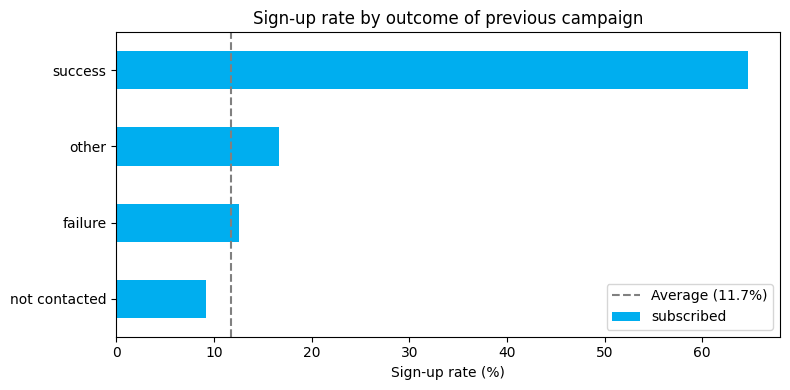

In [10]:
p = df_clean[df_clean["poutcome"] != "unknown"].groupby("poutcome")["subscribed"].mean() * 100
p = p.sort_values()

ax = p.plot(kind="barh", color="#00AEEF", figsize=(8, 4))
ax.axvline(baseline, color="grey", linestyle="--", label=f"Average ({baseline:.1f}%)")
ax.set_title("Sign-up rate by outcome of previous campaign")
ax.set_xlabel("Sign-up rate (%)")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
import statsmodels.formula.api as smf

model_df = df_clean[df_clean["poutcome"] != "unknown"].copy()
model_df["age_band"] = model_df["age_band"].astype(str)

model = smf.logit(
    "subscribed ~ C(age_band, Treatment('36-45'))"
    " + C(job, Treatment('blue-collar'))"
    " + C(poutcome, Treatment('not contacted'))"
    " + C(contact, Treatment('cellular'))",
    data=model_df).fit(disp=0)

me = model.get_margeff(dummy=True).summary_frame()
me["effect_pp"] = (me["dy/dx"] * 100).round(1)   # percentage-point change in sign-up probability
me["p_value"] = me["Pr(>|z|)"].round(3)
me[["effect_pp", "p_value"]]

,effect_pp,p_value
"C(age_band, Treatment('36-45'))[T.18-25]",10.4,0.000
"C(age_band, Treatment('36-45'))[T.26-35]",1.6,0.000
"C(age_band, Treatment('36-45'))[T.46-55]",-0.1,0.786
"C(age_band, Treatment('36-45'))[T.56-65]",3.0,0.000
"C(age_band, Treatment('36-45'))[T.66+]",19.0,0.000
"C(job, Treatment('blue-collar'))[T.admin.]",3.6,0.000
"C(job, Treatment('blue-collar'))[T.entrepreneur]",0.8,0.427
"C(job, Treatment('blue-collar'))[T.housemaid]",0.3,0.744
"C(job, Treatment('blue-collar'))[T.management]",4.5,0.000
"C(job, Treatment('blue-collar'))[T.retired]",5.4,0.000


Finding 5, logit model (average marginal effects): Controlling for job, previous outcome and channel, age still matters: over-65s are 19.0 percentage points and 18 to 25 year olds 10.4 points more likely to sign up than 36 to 45 year olds. Previous success is the strongest predictor (+43.8 points). The apparent advantage of previous non-responders over never-contacted customers is not significant once other factors are controlled for (p = 0.074). An unrecorded channel remains associated with an 8-point lower sign-up rate. These are associations from historical data, not causal effects.